# **Model Fine Tune with PyTorch**

Threre are several ways to do the fine-tune for a model. but we are considering only main two methods in this project.

They are:

* Fine-tune with all the parameters
* Fine-tune with the final layer only

In [1]:
import torch
import torch.nn as nn 
from tqdm import tqdm
import math
from time import time
import matplotlib.pyplot as plt
from urllib.request import urlopen
import pickle
import tarfile
import io
import os
import tempfile
from torch.utils.data import Dataset
from transformers import AutoTokenizer
from torch.utils.data import random_split
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence
from transformers import get_linear_schedule_with_warmup
from torch.nn import CrossEntropyLoss
from torch.optim import AdamW

C:\Users\Vish\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### **Import Dataset**

In [3]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/35t-FeC-2uN1ozOwPs7wFg.gz"

In [7]:
url_open = urlopen(url)
#convert to tar file
tar_file = tarfile.open(fileobj= io.BytesIO(url_open.read()))
temp_file = tempfile.TemporaryDirectory()
tar_file.extractall(temp_file.name)
tar_file.close()

Define IMDB Dataset Class


In [8]:
class IMDBDataset(Dataset):
    
    def __init__(self, root_dir, train = True):
        super().__init__()
        
        self.root_dir = os.path.join(root_dir,"train" if train else "test")
        self.negative_files = [os.path.join(self.root_dir, "neg",f) for f in os.listdir(os.path.join(self.root_dir,"neg")) if f.endswith('.txt')]
        self.positive_files = [os.path.join(self.root_dir,"pos",f) for f in os.listdir(os.path.join(self.root_dir,"pos")) if f.endswith(".txt")]
        
        self.files = self.negative_files + self.positive_files
        self.labels = [0] * len(self.negative_files) + [1] * len(self.positive_files)
        self.pos_idx = len(self.negative_files)
    
    def __len__(self):
        return len(self.files)
    
    def __getitem__(self, index):
        file_path = self.files[index]
        label = self.labels[index]
        
        with open(file_path, "r", encoding='utf-8') as file:
            content = file.read()
        return label, content

In [9]:
root_dir = temp_file.name + '/' + 'imdb_dataset'
train_dataset = IMDBDataset(root_dir,train=True)
test_dataset = IMDBDataset(root_dir,train=False)

In [10]:
start = train_dataset.pos_idx
for item in range(-10,10):
    print(train_dataset[start+item])

(0, "Yeti: Curse of the Snow Demon starts aboard a plane full of American high school teens who are on their way to play a football game in Japan, unfortunately during a fierce thunder storm their plane crashes in the Himalayas. Unlucky really. With some dead & some alive the survivors have to think about themselves & decide to wait it out until help comes. However just when they think their luck couldn't get any worse they soon discover that a huge, hairy Yeti type Abominable Snowman creature wants to kill & eat them all. Trapped, cold, starving & fighting for survival will help reach the stranded teens in time?<br /><br />Yeah, with a title like Yeti: Curse of the Snow Demon it can only mean one thing & that is that someone at the Sci-Fi Channel has made yet another 'Creature Feature' although to give these things a bit of variety the Sci-Fi Channel here in the UK are now dubbing them as a 'Beast Feast'! As if that will make any difference. Directed by Paul Ziller one has to say that

**Label Define**

In [11]:
imdb_label = {0: "negative review", 1: "positive review"}

In [12]:
num_class = 2

In [17]:
#define number of classes
num_class = len(set([label for label, text in train_dataset]))
print("Number of classes: ", num_class)

Number of classes:  2


### **Word Embeddings**

In [13]:
class WordEmbedding(nn.Module):
    
    def __init__(self, vocab_size, num_dims,freeze):
        super().__init__()
        self.embedding_layer = nn.Embedding(vocab_size, num_dims)
        self.embedding_layer.weight.requires_grad = freeze
    
    def forward(self, input_tokens):
        word_embed = self.embedding_layer(input_tokens)
        return word_embed

### **Positional Embeddigns**

In [14]:
class PositionalEmbedding(nn.Module):
    
    def __init__(self, max_seq_len, d_model,dropout):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        positions = torch.arange(0,max_seq_len).float().unsqueeze(1)
        
        pe = torch.zeros(max_seq_len,d_model)
        
        div_term = torch.exp(
            torch.arange(0,d_model,2).float() * (-math.log(10000)/d_model)
        )
        
        pe[:,0::2] = torch.sin(positions * div_term)
        pe[:,1::2] = torch.cos(positions * div_term)
        
        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)
        
    def forward(self, word_embeddings):
        
        word_embed_size = word_embeddings.size(1)
        positional_embeddings = word_embeddings + self.pe[:,0:word_embed_size,:]
        return self.dropout(positional_embeddings)

In [15]:
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

In [16]:
tokenizer("hi how are you?").input_ids

[101, 7632, 2129, 2024, 2017, 1029, 102]

In [17]:
#define yield iterator for iteratable tokenization
def yield_tokens(dataset):
    for label,text in dataset:
        yield tokenizer(text)

In [18]:
yield_tokens("hi how are you?")

<generator object yield_tokens at 0x000002BB8C54E7A0>

In [19]:
PAD_IDX,UNK_IDX,EOS_IDX  = 0,1,2
special_tokens = ['<pad>','<unk>','<eos>']

In [20]:
vocab_size = tokenizer.vocab_size

#### **Define Data Splits**

In [21]:
num_train = int(0.8 * len(train_dataset))
print(f"num_train:{num_train}")

num_valid = len(train_dataset) - num_train
print(f"num_valid:{num_valid}")

num_train:20000
num_valid:5000


In [22]:
train_split, valid_split = random_split(train_dataset,[num_train,num_valid])

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#### **Define Collate Function**

In [24]:
def collate_func (batch):
    
    # label_list, text_list = [], []
    
    # for label_, text_ in batch:
    #     label_list.append(label_)
    #     text_list.append(torch.tensor(tokenizer(text_).input_ids, dtype=torch.int64))
    
    # label_list = torch.tensor(label_list, dtype=torch.int64)
    
    # #padding the token ids
    # text_list = pad_sequence(text_list,batch_first=True, padding_value=PAD_IDX)
    # return label_list.to(device), text_list.to(device)
    
    labels, texts = zip(*batch)   # unpack batch
    
    # Batch tokenization (FAST + CORRECT)
    encoded = tokenizer(
        list(texts),
        padding=True,              # dynamic padding
        truncation=True,           # avoid long sequence issues
        return_tensors='pt'
    )
    
    input_ids = encoded['input_ids']          # (B, L)
    attention_mask = encoded['attention_mask'] # (B, L)
    
    labels = torch.tensor(labels, dtype=torch.long)
    
    return labels.to(device), input_ids.to(device), attention_mask.to(device)
    

#### **Define Data Loaders**

In [25]:
batch_size = 32

In [26]:
train_dataloader = DataLoader(train_split,batch_size=batch_size,shuffle=True,collate_fn=collate_func)

valid_dataloader = DataLoader(valid_split, batch_size=batch_size, shuffle=True, collate_fn=collate_func)

test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_func)

In [27]:
#test the data loaders
label, text = next(iter(valid_split))
label,text

(0,
 'The TV guide calls this movie a mystery. What is a mystery to me is how is it possible that a culture that can produce such intricate and complex classical music and brilliant mathematicians cannot produce a single film that would rise above the despicable trash level this film so perfectly represents. This is Bollywood at its best/worst, I honestly cannot tell the difference. Nauseatingly sweet, kitschy clichés on every level, story-line, situations, dialog, music and choreography. To put it bluntly, you must be a retard to enjoy it. I watched it to satisfy my cultural curiosity, but there were times when I had to walk away from it, because I could not take it any more. The only redeeming quality of the movie is the exquisite beauty of the leading actresses. <br /><br />')

### **Define Model**

In [28]:
class NNClassificationModel (nn.Module):
    
    def __init__(self, vocab_size, d_model, nhead, n_layers, dropout, dim_feedforward, 
                 activation, max_seq_len ,num_class, freeze = False):
        super().__init__()
        
        self.embeddings = WordEmbedding(vocab_size,d_model,freeze)
        self.positional_embeddings = PositionalEmbedding(max_seq_len,d_model, dropout)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead,
                                                        activation=activation, 
                                                        dim_feedforward=dim_feedforward,
                                                        batch_first=True)
        
        self.transformer = nn.TransformerEncoder(encoder_layer=encoder_layer,
                                                num_layers=n_layers)
        
        self.classify_fc = nn.Linear(d_model, num_class)
        
        self.d_model = d_model
        
    def forward(self, input_tokens, attention_mask):
        
        embed_out = self.embeddings(input_tokens) * math.sqrt(self.d_model)
        
        pos_embed_out = self.positional_embeddings(embed_out)
        
        src_key_padding_mask = (attention_mask == 0)
        
        transformer_out = self.transformer(pos_embed_out, src_key_padding_mask = src_key_padding_mask)
        
        #we need to get a mean of all the tokens in a sequence before feed to the linear layer
        transformer_out_mean = transformer_out.mean(dim = 1)
        classify_out = self.classify_fc(transformer_out_mean)
        
        return classify_out

In [29]:
d_model = 128
dim_feedforward = 128
nheads = 2
n_layers = 2
dropout = 0.1
activation = 'relu'

In [30]:
## Define model instance
classify_model = NNClassificationModel(vocab_size,d_model, nheads,n_layers, dropout,dim_feedforward
                                       ,activation, 2000,num_class)

#### **Define Model Prediction**

In [31]:
def model_predict (model: NNClassificationModel, input_sentence):
        
    with torch.no_grad():
        #[batch_size, seq_len]
        input_ids = torch.tensor(tokenizer(input_sentence).input_ids, dtype=torch.int64).unsqueeze(0)
        attention_mask = torch.tensor(tokenizer(input_sentence).attention_mask, dtype=torch.int64).unsqueeze(0)
        predict_tokens = model(input_ids,attention_mask)
        print(f"predict tokens: {predict_tokens}")
        output = torch.argmax(predict_tokens, dim=1).item()
        return imdb_label[output]
        

In [32]:
sample = "I does like sports and stuff"
predict = model_predict(classify_model,sample)
print(f"predicted label: {predict}")

predict tokens: tensor([[-0.0906,  0.2134]])
predicted label: positive review


#### **Define Model Evaluation**

In [33]:
def model_evaluate (model:NNClassificationModel,dataset:DataLoader):
    
    model.eval()
    total_accuracy = 0
    total_count = 0
    
    with torch.no_grad():
        
        for label, input_ids, attention_mask in dataset:
            
            output = model(input_ids,attention_mask)
            output_label = torch.argmax(output, dim =1)
            total_accuracy += (output_label == label).sum().item()
            total_count += label.size(0)
    return total_accuracy / total_count 

#### **Define Model Training**

##### Define Model Parameters 

In [34]:
loss_func = CrossEntropyLoss()
optimizer = AdamW(classify_model.parameters(),lr = 1e-4)

In [35]:
num_epochs = 1

total_steps = num_epochs * len(train_dataloader)
warm_steps = int(total_steps * 0.1)
lr_scheduler = get_linear_schedule_with_warmup(optimizer,
                                               num_training_steps=total_steps,
                                               num_warmup_steps=warm_steps)


In [36]:
def save_list_to_file (list_obj, filename):
    
    with open(filename, "wb") as f:
        pickle.dump(list_obj, f)    

def load_list_from_file (filename):
    
    with open(filename, "rb") as f:
        loaded_list = pickle.load(f)
    return loaded_list

In [37]:
def model_train (model:NNClassificationModel, traindataloader:DataLoader,validdataloader:DataLoader, optimizer:AdamW, 
                 loss_func:CrossEntropyLoss, lr_scheduler, epochs = num_epochs, save_dir = "", file_name = None):
    
    cum_loss_list = []
    acc_epoch = []
    acc_old = 0
    
    model_path = os.path.join(save_dir,file_name)
    
    acc_dir = os.path.join(save_dir,os.path.splitext(file_name)[0] + "_acc")
    loss_dir = os.path.join(save_dir, os.path.splitext(file_name)[0] + "_loss")
    
    start_time = time()
    
    for epoch in tqdm(range(1,epochs+1)):
        
        model.train()
        epoch_loss = 0
        
        for idx, (label,input_ids, attention_mask) in enumerate(traindataloader):
            optimizer.zero_grad()
            predict = model(input_ids, attention_mask)
            loss = loss_func(predict,label)
            
            loss.backward()
            epoch_loss += loss.item()
            torch.nn.utils.clip_grad_norm_(model.parameters(),0.1)
            optimizer.step()
            lr_scheduler.step()
        
        print(f"Epoch {epoch}/{epochs} - Loss: {epoch_loss}")
    
        cum_loss_list.append(epoch_loss)
        acc_val = model_evaluate(model,valid_dataloader)
        acc_epoch.append(acc_val)
        
        if model_path and acc_val > acc_old:
            acc_old = acc_val
            print(f"Accuacy value: {acc_val}")
            
            if save_dir is not None:
                print("save model from epoch:", epoch)
                torch.save(model.state_dict(),model_path)
                save_list_to_file(list_obj=acc_epoch, filename="acc_dir")
                save_list_to_file(list_obj=cum_loss_list, filename="loss_dir")
    
    end_time = time()
    print(f"training time: {end_time-start_time}")
            
    
    

In [38]:
# model_train(classify_model,train_dataloader,valid_dataloader,optimizer,loss_func,
#             lr_scheduler,file_name="classification_model")

#### **Load the Saved Model** 

In [39]:
#make model instance
load_classify_model = NNClassificationModel(vocab_size,d_model, nheads,n_layers, dropout,dim_feedforward
                                       ,activation, 2000,num_class)

#load the weights to model instance
load_classify_model.load_state_dict(torch.load("classification_model"))
load_classify_model.eval()

NNClassificationModel(
  (embeddings): WordEmbedding(
    (embedding_layer): Embedding(30522, 128)
  )
  (positional_embeddings): PositionalEmbedding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (classify_fc): Linear(in_features=128, out_features=2, bias=True)
)

In [40]:
acc_list = load_list_from_file("acc_dir")
loss_list = load_list_from_file("loss_dir")
acc_list, loss_list

([0.4922], [30896.995777130127])

In [41]:
def plot_graphs(loss, acc):
    
    fig, ax1 = plt.subplots()
    color = 'tab:red'
    
    ax1.plot(loss, color = color)
    ax1.set_xlabel('epoch', color = color)
    ax1.set_ylabel('total loss', color= color)
    ax1.tick_params('y', color=color)
    
    ax2 = ax1.twinx()
    color = 'tab:blue'
    
    ax2.plot(acc, color=color)
    ax2.set_ylabel('total accuracy', color= color)
    ax2.tick_params('y', color=color)
    
    fig.tight_layout()
    
    plt.show()
    

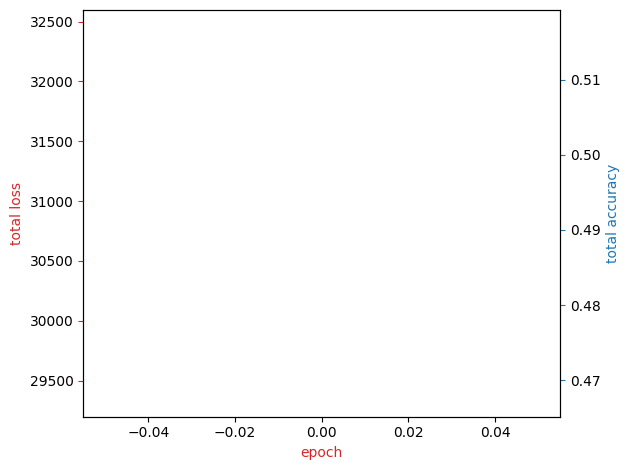

In [42]:
plot_graphs(loss_list, acc_list) #nothing showing beacuse we have trained the model for 1 epoch

The following line loads the model fine-tuned for 100 epochs on the full IMDB train set and evaluates its performance on the IMDB test set.


In [43]:
acc_urlopened = urlopen('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/sybqacL5p1qeEO8d4xRZNg/model-IMDB%20dataset%20small2-acc')
loss_urlopened = urlopen('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/eOt6woGoaOB565T0RLH5WA/model-IMDB%20dataset%20small2-loss')
acc_epoch = pickle.load(acc_urlopened)
cum_loss_list = pickle.load(loss_urlopened)

**This graphs shows the loss and accuracy behaviour for model whicg train the total layers of the model** 

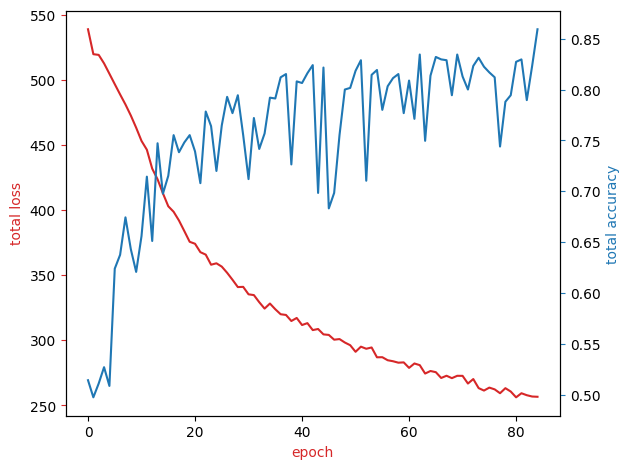

In [44]:
plot_graphs(cum_loss_list, acc_epoch)

### **Fine tune the Final Layer Only**

In [45]:
final_layer_model = NNClassificationModel(vocab_size,d_model, nheads,n_layers, dropout,dim_feedforward
                                       ,activation, 2000,num_class)

final_layer_model.load_state_dict(torch.load("classification_model"))
final_layer_model.eval()

NNClassificationModel(
  (embeddings): WordEmbedding(
    (embedding_layer): Embedding(30522, 128)
  )
  (positional_embeddings): PositionalEmbedding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (classify_fc): Linear(in_features=128, out_features=2, bias=True)
)

### Set the all the parameters gradient requires **false** for fine tune the last layer

**Step 01: Freeze the all layers in the model**

In [46]:
for param in final_layer_model.parameters():
    param.requires_grad_ = False

**Step 02: Replace the final layer to reflect the fact that you are solving a two-class problem. Note that the new layer will be unfrozen.** 

In [47]:
dim = final_layer_model.classify_fc.in_features
final_layer_model.classify_fc = nn.Linear(dim, 2)

In [48]:
final_layer_model.to(device)

NNClassificationModel(
  (embeddings): WordEmbedding(
    (embedding_layer): Embedding(30522, 128)
  )
  (positional_embeddings): PositionalEmbedding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (classify_fc): Linear(in_features=128, out_features=2, bias=True)
)

In [ ]:
#train the model
model_train(final_layer_model,train_dataloader, valid_dataloader,optimizer, loss_func,
            lr_scheduler, file_name="final_layer_trained_model.pth")

**This graph shows the loss and accuracy behaviour of the model which have trained only relevant layers (Fine tune the final layer only)**

The following line loads the model fine-tuned for 100 epochs on the full IMDB train set and evaluates its performance on the IMDB test set.


In [51]:
acc_urlopened = urlopen('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UdR3ApQnxSeV2mrA0CbiLg/model-fine2-acc')
loss_urlopened = urlopen('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/rWGDIF-uL2dEngWcIo9teQ/model-fine2-loss')

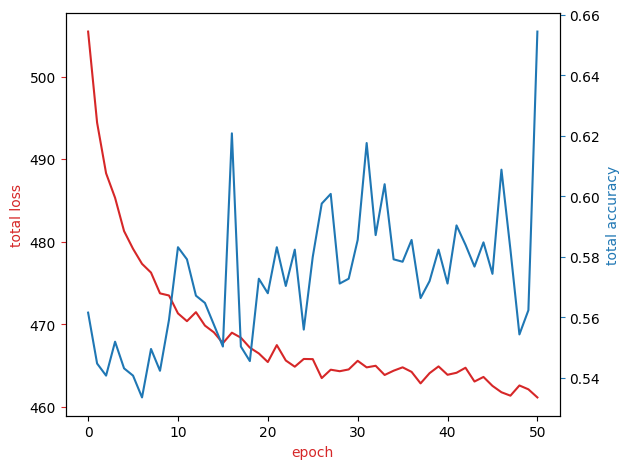

In [52]:
acc_final_layer_model  = pickle.load(acc_urlopened)
loss_final_layer_model = pickle.load(loss_urlopened)
plot_graphs(loss_final_layer_model,acc_final_layer_model)

The previous code demonstrates that fine-tuning only the final layer requires considerably less time compared to fine-tuning the entire model. However, the model’s performance is notably lower when only the last layer is unfrozen, achieving 64% accuracy, whereas fine-tuning all layers results in a much higher accuracy of 86%.